# LightGBM Classification

# Load pipeline + predict
##### 1. Load and Explore the Dataset

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon
from scipy.spatial import Voronoi, voronoi_plot_2d, ConvexHull
import joblib

In [2]:
# Load the saved LightGBM-Bundle
bundle = joblib.load("lgbm_bundle.joblib")
pipe     = bundle["pipe"]
num_cols = bundle["num_cols"]
cat_cols = bundle["cat_cols"]

In [3]:
# Selected match_id for analysis
match_id = "DFL-MAT-J03YLO"

In [4]:
# Load aggregated dataset
csv_files = glob.glob(f"tracking_raw_cleaned_{match_id}.csv")
if not csv_files:
    raise FileNotFoundError("No CSV files found for prediction.")
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print(f"Loaded {len(df)} rows from {len(csv_files)} CSV files")

Loaded 1680 rows from 1 CSV files


In [5]:
# define home and away team codes
home_team = df['home_team_code'][0]
print(f"home Team is: {home_team}")

away_team = df['away_team_code'][0]
print(f"away Team is: {away_team}")

home Team is: WOB
away Team is: SVD


In [6]:
# Load aggregated dataset
csv_files = glob.glob(f"tracking_features_{match_id}.csv")
if not csv_files:
    raise FileNotFoundError("No CSV files found for prediction.")
df_features = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print(f"Loaded {len(df_features)} rows from {len(csv_files)} CSV files")

Loaded 168 rows from 1 CSV files


In [7]:
# merge features with original df to get team codes
df = df.merge(
    df_features,
    on=["team_code", "window_global", "game_section"],
    how="left"
)
df.head()

,match_title,team_code,home_team_code,away_team_code,player_name,game_section,x_norm_mean,x_norm_std,y_norm_mean,y_norm_std,...,centroid_y,width,length,area,ratio,dist_mean,dist_std,x_norm_std_mean,y_norm_std_mean,speed_mean_team
0,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,A. Müller,firstHalf,-0.075888,0.177637,0.117960,0.377517,...,0.010505,1.986293,3.424055,6.801177,0.5801,1.048365,0.474651,0.234167,0.294859,10.245883
1,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Klarer,firstHalf,-0.613232,0.111788,-0.145861,0.274334,...,0.010505,1.986293,3.424055,6.801177,0.5801,1.048365,0.474651,0.234167,0.294859,10.245883
2,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,C. Zimmermann,firstHalf,-0.488312,0.152379,0.920704,0.238838,...,0.010505,1.986293,3.424055,6.801177,0.5801,1.048365,0.474651,0.234167,0.294859,10.245883
3,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,E. Karic,firstHalf,-0.125018,0.316417,1.722004,0.260297,...,0.010505,1.986293,3.424055,6.801177,0.5801,1.048365,0.474651,0.234167,0.294859,10.245883
4,VfL Wolfsburg:SV Darmstadt 98,SVD,WOB,SVD,F. Nürnberger,firstHalf,0.141117,0.291699,-1.702051,0.399483,...,0.010505,1.986293,3.424055,6.801177,0.5801,1.048365,0.474651,0.234167,0.294859,10.245883


In [8]:
# Columns in df
df.columns

Index(['match_title', 'team_code', 'home_team_code', 'away_team_code',
       'player_name', 'game_section', 'x_norm_mean', 'x_norm_std',
       'y_norm_mean', 'y_norm_std', 'speed_mean', 'window',
       'dominant_possession', 'window_start_sec', 'window_end_sec',
       'window_duration_sec', 'dominant_possession_num',
       'dominant_possession_team', 'window_global', 'possession_state',
       'centroid_x', 'centroid_y', 'width', 'length', 'area', 'ratio',
       'dist_mean', 'dist_std', 'x_norm_std_mean', 'y_norm_std_mean',
       'speed_mean_team'],
      dtype='object')

##### 2. Prepare Features for Prediction

In [9]:
# Ensure required feature columns exist
required_feats = [
    "centroid_x", "centroid_y", "width", "length",
    "dist_mean", "dist_std"
]

# Ensure numeric and categorical columns match the trained pipeline
for c in num_cols:
    if c not in df.columns:
        df[c] = 0.0
for c in cat_cols:
    if c not in df.columns:
        df[c] = "Unknown"

X_infer = df[num_cols + cat_cols]

##### 3. Predict Formations

In [10]:
print("\nPredicting formations using LightGBM model...")
y_pred = pipe.predict(X_infer)
df["predicted_formation_LGBM"] = y_pred


Predicting formations using LightGBM model...


/home/falih/Mastercode/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


##### 4. Aggregate Predictions by Team and Tactical Window

In [11]:
def mode_or_first(s):
    """Return the most frequent formation in the group."""
    m = s.mode()
    return m.iat[0] if not m.empty else s.iloc[0]

group_keys = [
    "match_title", "team_code", "window_global",
    "dominant_possession_team", "game_section"
]
group_keys = [k for k in group_keys if k in df.columns]

results = (
    df.groupby(group_keys, dropna=False)["predicted_formation_LGBM"]
      .agg(mode_or_first)
      .reset_index()
)

print("\nSample of aggregated formation predictions:")
results.head()


Sample of aggregated formation predictions:


,match_title,team_code,window_global,dominant_possession_team,game_section,predicted_formation_LGBM
0,VfL Wolfsburg:SV Darmstadt 98,SVD,0,Out_of_possession,firstHalf,5-3-2
1,VfL Wolfsburg:SV Darmstadt 98,SVD,2,In_possession,firstHalf,4-4-2
2,VfL Wolfsburg:SV Darmstadt 98,SVD,4,Out_of_possession,firstHalf,5-3-2
3,VfL Wolfsburg:SV Darmstadt 98,SVD,6,In_possession,firstHalf,3-1-4-2
4,VfL Wolfsburg:SV Darmstadt 98,SVD,8,In_possession,firstHalf,3-1-4-2


#### 5. save results

In [12]:
# results.to_csv(f"predicted_formations_LGBM_{match_id}.csv", index=False)
# print(f"\nSaved predictions → predicted_formations_LGBM_{match_id}.csv")

# Soccer Pitch
#### Draw a standard football pitch centered at (0,0) in meters.

In [13]:
# Function to draw a soccer pitch
def draw_soccer_pitch(
    ax=None,
    figsize=(12, 8),
    pitch_length_m: float = 105.0,
    pitch_width_m: float = 68.0,
    scale: float = 1.0,           # switch scale: 1 (raw) / 15 (after normalization)
    line_color: str = "black",
    line_width: float = 1.0,
):
    # Create axes if not provided
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    # Marking dimensions (meters)
    CENTER_CIRCLE_R = 9.15
    SPOT_R = 0.30
    PENALTY_SPOT_DIST = 11.0
    PA_DEPTH, PA_WIDTH = 16.5, 40.32
    GA_DEPTH, GA_WIDTH = 5.5, 18.32
    MARGIN = 1.0

    # Pitch extents (centered)
    L = pitch_length_m / scale
    W = pitch_width_m / scale
    half_L, half_W = L / 2.0, W / 2.0
    cc_r = CENTER_CIRCLE_R / scale
    spot_r = SPOT_R / scale
    pa_d, pa_w = PA_DEPTH / scale, PA_WIDTH / scale
    ga_d, ga_w = GA_DEPTH / scale, GA_WIDTH / scale
    pen_spot = PENALTY_SPOT_DIST / scale
    margin = MARGIN / scale

    # Field outline
    ax.add_patch(plt.Rectangle((-half_L, -half_W), L, W, fill=False,
                               color=line_color, linewidth=line_width))
    # Halfway line & center marks
    ax.plot([0, 0], [-half_W, half_W], color=line_color, linewidth=line_width)
    ax.add_patch(plt.Circle((0, 0), cc_r, fill=False, color=line_color, linewidth=line_width))
    ax.add_patch(plt.Circle((0, 0), spot_r, color=line_color))

    # Penalty areas
    ax.add_patch(plt.Rectangle((-half_L, -pa_w/2), pa_d, pa_w, fill=False,
                               color=line_color, linewidth=line_width))
    ax.add_patch(plt.Rectangle((half_L - pa_d, -pa_w/2), pa_d, pa_w, fill=False,
                               color=line_color, linewidth=line_width))

    # Goal areas
    ax.add_patch(plt.Rectangle((-half_L, -ga_w/2), ga_d, ga_w, fill=False,
                               color=line_color, linewidth=line_width))
    ax.add_patch(plt.Rectangle((half_L - ga_d, -ga_w/2), ga_d, ga_w, fill=False,
                               color=line_color, linewidth=line_width))

    # Penalty spots
    ax.add_patch(plt.Circle((-half_L + pen_spot, 0), spot_r, color=line_color))
    ax.add_patch(plt.Circle((half_L - pen_spot, 0), spot_r, color=line_color))

    # Axes
    ax.set_xlim(-half_L - margin, half_L + margin)
    ax.set_ylim(-half_W - margin, half_W + margin)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

#### Plot a team's predicted formation and positional shape for a window

In [17]:
def plot_predicted_team_formation(
    df: pd.DataFrame,
    team_code: str,
    title: str = "Predicted Team Formation",
    save_path: str | None = None,
    point_color: str = "green",
    show_ellipses: bool = True,
    label: bool = True,
):

    # Filter the dataframe for the selected team
    team_df = df[df["team_code"] == team_code].copy()
    if team_df.empty:
        print(f"No data found for team {team_code} in this predicted window.")
        return None

    # Create pitch figure
    fig, ax = plt.subplots(figsize=(9, 6))
    try:
        draw_soccer_pitch(ax=ax, scale=15)  # if helper supports scaling
    except TypeError:
        draw_soccer_pitch(ax=ax)  # fallback for basic pitch function

    # Context info for the title
    window = team_df["window"].iloc[0] if "window" in team_df.columns else None
    possession = team_df.get("dominant_possession_team", pd.Series(["unknown"])).iloc[0]
    duration = team_df.get("window_duration_sec", pd.Series([pd.NA])).iloc[0]
    predicted = team_df.get("predicted_formation_LGBM", pd.Series(["unknown"])).iloc[0]

    if pd.notna(duration):
        dur_fmt = f"{float(duration):.2f}".rstrip("0").rstrip(".")
    else:
        dur_fmt = "unknown"

    # Plot players (mean normalized positions)
    ax.scatter(
        team_df["x_norm_mean"],
        team_df["y_norm_mean"],
        s=100,
        color=point_color,
        zorder=5,
    )

    # Draw 1σ ellipses around each player's mean position
    if show_ellipses:
        for _, r in team_df.iterrows():
            ellipse = Ellipse(
                (r["x_norm_mean"], r["y_norm_mean"]),
                width=2 * r["x_norm_std"],
                height=2 * r["y_norm_std"],
                facecolor="grey",
                edgecolor="grey",
                alpha=0.2,
                zorder=4,
            )
            ax.add_patch(ellipse)

    # Add player name labels
    if label and "player_name" in team_df.columns:
        x_off, y_off = 0.14, 0.07  # label offsets
        for _, r in team_df.iterrows():
            ax.text(
                r["x_norm_mean"] + x_off,
                r["y_norm_mean"] + y_off,
                str(r["player_name"]),
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
                zorder=6,
            )

    # Dynamic title with contextual information
    title_parts = []
    if window is not None:
        title_parts.append(f"Window {window}")
    title_parts.append(f"Predicted: {predicted}")
    title_parts.append(str(possession))
    title_parts.append(f"Duration: {dur_fmt} s")

    ax.set_title(f"{title} — " + " — ".join(title_parts), fontsize=14)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close(fig)
    else:
        plt.show()


In [ ]:
# Show unique values in the 'window' column
df['window'].unique()

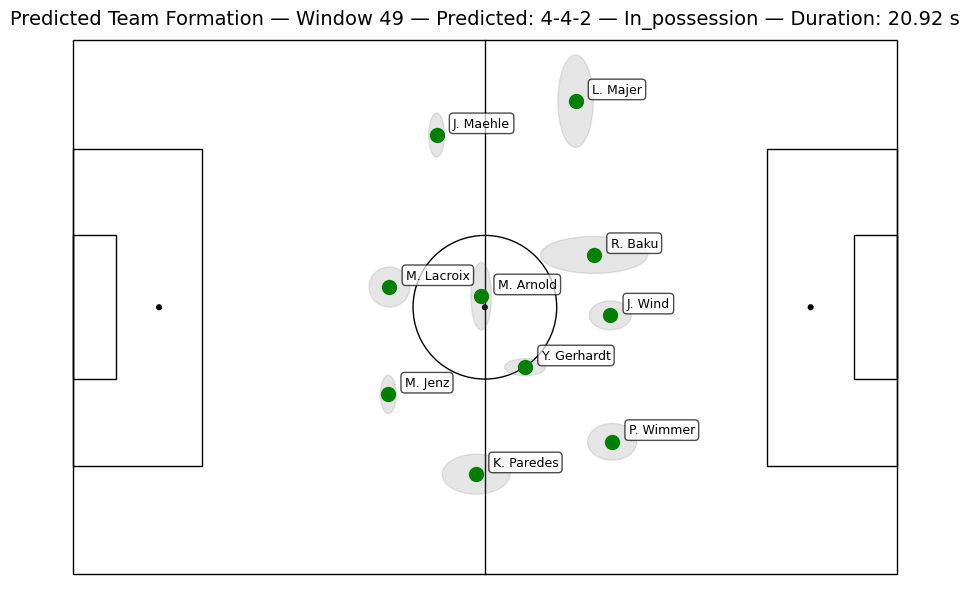

In [18]:
team_shapes_window = df[df['window'] == 49 ]  # Filter for the first window
plot_predicted_team_formation(team_shapes_window, team_code= home_team)
# plot_predicted_team_formation_and_shape(team_shapes_window, team_code= away_team)

/tmp/ipykernel_19602/41413576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="predicted_formation_LGBM", y="area", palette="viridis")


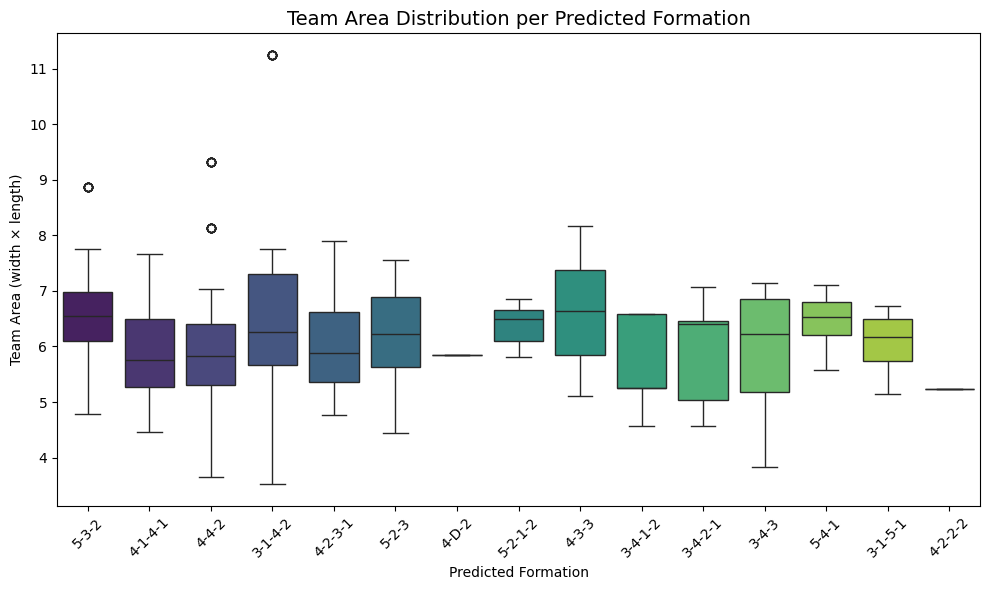

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="predicted_formation_LGBM", y="area", palette="viridis")
plt.title("Team Area Distribution per Predicted Formation", fontsize=14)
plt.xlabel("Predicted Formation")
plt.ylabel("Team Area (width × length)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_19602/4215940557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="predicted_formation_LGBM", y="ratio", palette="coolwarm")


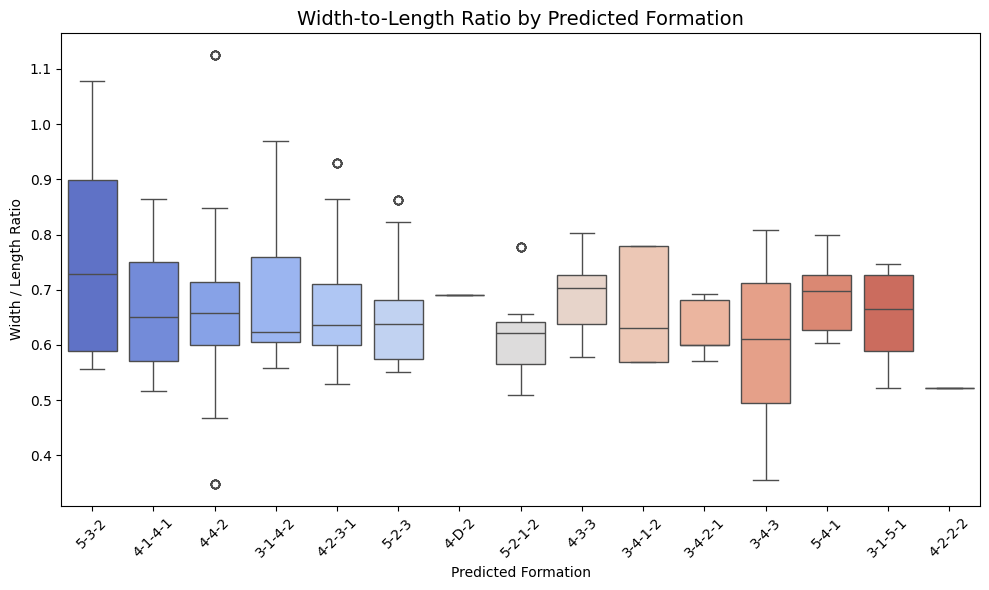

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="predicted_formation_LGBM", y="ratio", palette="coolwarm")
plt.title("Width-to-Length Ratio by Predicted Formation", fontsize=14)
plt.xlabel("Predicted Formation")
plt.ylabel("Width / Length Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


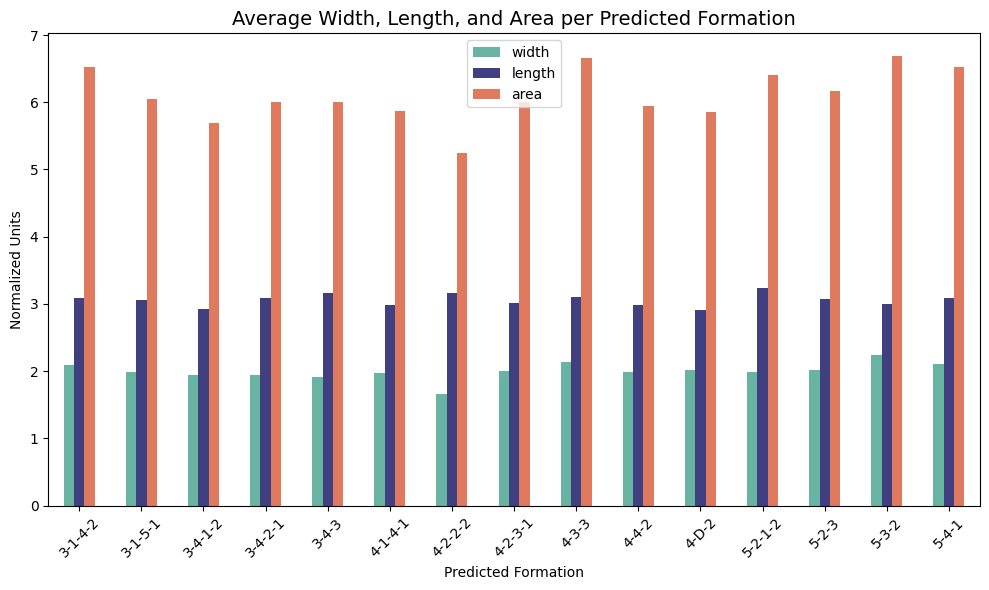

In [21]:
agg = df.groupby("predicted_formation_LGBM")[["width", "length", "area"]].mean().reset_index()

agg.plot(
    x="predicted_formation_LGBM",
    kind="bar",
    figsize=(10, 6),
    rot=45,
    color=["#69b3a2", "#404080", "#e07a5f"]
)
plt.title("Average Width, Length, and Area per Predicted Formation", fontsize=14)
plt.ylabel("Normalized Units")
plt.xlabel("Predicted Formation")
plt.tight_layout()
plt.show()


In [ ]:
def plot_predicted_team_formation(
    df: pd.DataFrame,
    team_code: str,
    title: str = "Predicted Team Formation",
    save_path: str | None = None,
    point_color: str = "green",
    show_ellipses: bool = True,
    label: bool = True,
    show_voronoi: bool = True,
    show_convex_hull: bool = True,
    show_centroid: bool = True,
):
    """
    Plot predicted team formation with optional Voronoi, convex hull, and centroid overlay.
    The centroid is shown with a thick red cross, and the legend is moved outside the pitch.
    """

    # --- Filter Data ---
    team_df = df[df["team_code"] == team_code].copy()
    if team_df.empty:
        print(f"No data found for team {team_code}.")
        return None

    # --- Create Pitch ---
    fig, ax = plt.subplots(figsize=(9, 6))
    try:
        draw_soccer_pitch(ax=ax, scale=15)
    except TypeError:
        draw_soccer_pitch(ax=ax)

    # --- Context Info ---
    window = team_df.get("window", pd.Series([None])).iloc[0]
    possession = team_df.get("dominant_possession_team", pd.Series(["unknown"])).iloc[0]
    duration = team_df.get("window_duration_sec", pd.Series([pd.NA])).iloc[0]
    predicted = team_df.get("predicted_formation_LGBM", pd.Series(["unknown"])).iloc[0]
    dur_fmt = f"{float(duration):.2f}".rstrip("0").rstrip(".") if pd.notna(duration) else "unknown"

    # --- Player Points ---
    ax.scatter(
        team_df["x_norm_mean"],
        team_df["y_norm_mean"],
        s=110,
        color=point_color,
        edgecolors="black",
        zorder=5,
        label="Players"
    )

    # --- Optional: 1σ Ellipses ---
    if show_ellipses:
        for _, r in team_df.iterrows():
            ellipse = Ellipse(
                (r["x_norm_mean"], r["y_norm_mean"]),
                width=2 * r["x_norm_std"],
                height=2 * r["y_norm_std"],
                facecolor="grey",
                edgecolor="none",
                alpha=0.25,
                zorder=4,
            )
            ax.add_patch(ellipse)

    # --- Optional: Voronoi Diagram ---
    if show_voronoi and len(team_df) >= 4:
        points = team_df[["x_norm_mean", "y_norm_mean"]].values
        vor = Voronoi(points)
        voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="lightblue", line_width=1, alpha=0.6, zorder=2)

    # --- Optional: Convex Hull (Team Boundary) ---
    if show_convex_hull and len(team_df) >= 3:
        points = team_df[["x_norm_mean", "y_norm_mean"]].values
        hull = ConvexHull(points)
        hull_polygon = Polygon(points[hull.vertices], closed=True, facecolor="none", edgecolor="orange", lw=2, zorder=3)
        ax.add_patch(hull_polygon)

    # --- Optional: Centroid ---
    if show_centroid:
        centroid_x = team_df["x_norm_mean"].mean()
        centroid_y = team_df["y_norm_mean"].mean()
        ax.scatter(
            centroid_x,
            centroid_y,
            color="red",
            s=250,
            marker="+",
            linewidths=3.5,  # thick cross
            zorder=8,
            label="Centroid"
        )

    # --- Player Labels ---
    if label and "player_name" in team_df.columns:
        for _, r in team_df.iterrows():
            ax.text(
                r["x_norm_mean"] + 0.12,
                r["y_norm_mean"] + 0.06,
                str(r["player_name"]),
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6),
                zorder=7,
            )

    # --- Title ---
    title_parts = []
    if window is not None:
        title_parts.append(f"Window {window}")
    title_parts.append(f"Predicted: {predicted}")
    title_parts.append(str(possession))
    title_parts.append(f"Duration: {dur_fmt} s")

    ax.set_title(f"{title} — " + " — ".join(title_parts), fontsize=13)

    # --- Legend outside pitch (so it doesn't overlap players) ---
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for legend
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


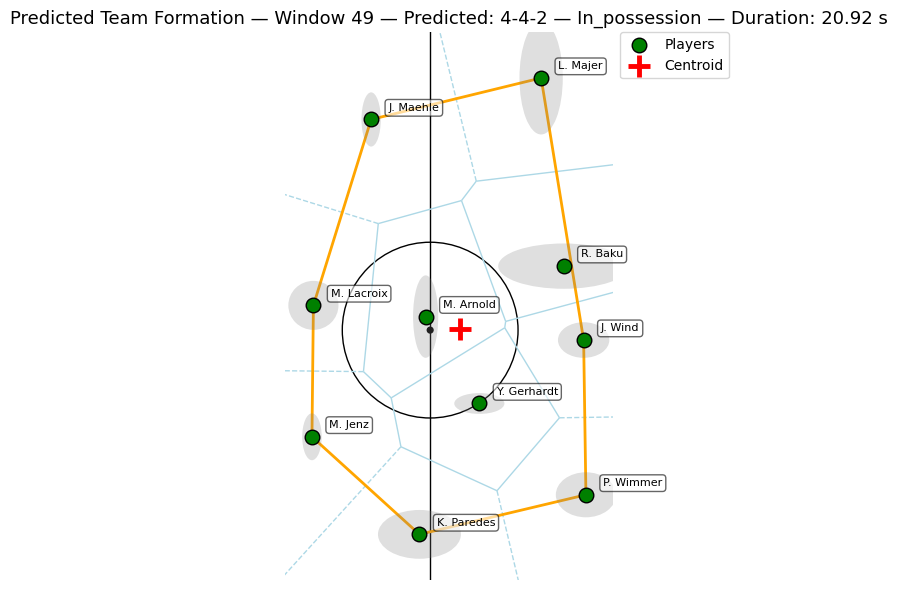

In [23]:
team_shapes_window = df[df['window'] == 49 ]  # Filter for the first window
plot_predicted_team_formation(team_shapes_window, team_code= home_team)
# plot_predicted_team_formation_and_shape(team_shapes_window, team_code= away_team)